In [1]:
# S.T.E.P. 1: Загружаем датасет DS_Wine и смотрим на него

# Импортируем нужные библиотеки
from sklearn.datasets import load_wine
import pandas as pd
import numpy as np

In [2]:
DS_Wine = load_wine()
# 2. Смотрим, что внутри: описание, признаки, классы
print("=== Описание датасета ===\n")
print(DS_Wine.DESCR)  # выведет подробное описание на английском

print("\n=== Признаки (feature names) ===")
print(DS_Wine.feature_names) # это атрибуты-столбцы - из таблицы выше

print("\n=== Целевые классы (target names) ===")
print(DS_Wine.target_names)   # ['class_0', 'class_1', 'class_2'] – но мы знаем, что это сорта

# 3. Преобразуем в удобную таблицу pandas DataFrame
df = pd.DataFrame(DS_Wine.data, columns=DS_Wine.feature_names)
df['target'] = DS_Wine.target  # добавляем столбец с классом

print("\n=== Первые 5 строк данных ===")
print(df.head())

# 4. Базовая информация: размер, пропуски, типы данных
print("\n=== Информация о датафрейме ===")
print(df.info())

# 5. Описательная статистика по признакам (среднее, мин, макс и т.д.)
print("\n=== Описательная статистика ===")
print(df.describe())

# 6. Проверка баланса классов: сколько образцов в каждом классе
print("\n=== Распределение классов ===")
print(df['target'].value_counts())

=== Описание датасета ===

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                 

- `wine.DESCR` – полное описание датасета (на английском, но можно перевести)
    
- `df.head()` – табличку с первыми 5 винами, их 13 признаками и классом
    
- `df.info()` – покажет, что нет пропусков, 178 строк, все типы float64, кроме класса (int)
    
- `df.describe()` – средние, стандартные отклонения, минимумы-максимумы. Обрати внимание: масштабы признаков разные (например, алкоголь ~13, магний ~100). Это важно для метрических методов – потом будем **нормализовывать**.
    
- `value_counts()` – убедимся, что классы примерно равны (около 60 образцов на класс).

Всего сортов три:
>#DEEP:
- **Класс 0** – первая провинция  
- **Класс 1** – вторая провинция  
- **Класс 2** – третья провинция  

Для каждого образца вина (всего их **178**) ты сделал 13 химических измерений (признаков). Вот они, как в реальном протоколе:

| № признака | Название (и что это значит "на пальцах")                                 |     |
| ---------- | ------------------------------------------------------------------------ | --- |
| 1          | Алкоголь – сколько градусов                                              |     |
| 2          | Яблочная кислота – одна из кислот, влияет на вкус                        |     |
| 3          | Зола – минеральный остаток после сжигания                                |     |
| 4          | Щёлочность золы – насколько щелочная зола                                |     |
| 5          | Магний – содержание магния                                               |     |
| 6          | Общий фенолы – антиоксиданты, влияют на цвет и вкус                      |     |
| 7          | Флавоноиды – подкласс фенолов (более полезные)                           |     |
| 8          | Нефлавоноидные фенолы – остальные фенолы                                 |     |
| 9          | Проантоцианины – вещества, дающие терпкость                              |     |
| 10         | Интенсивность цвета                                                      |     |
| 11         | Оттенок цвета                                                            |     |
| 12         | OD280/OD315 – отношение оптических плотностей (связано с возрастом вина) |     |
| 13         | Пролин – аминокислота                                                    |     |

Все эти числа – **вещественные** (с плавающей точкой), разные по масштабу. Например, алкоголь от 11% до 15%, а магний – от 70 до 160.

**Ключевая идея:** Вина одного сорта будут **похожи** по этим признакам (расстояние между ними маленькое), а разных сортов – разные.

>#MAKEME: **разделить данные на train и test**
# Task 1: Hold-out на train/test данные

In [3]:
# Task 1: Hold-out разбиение Wine на train/test

from sklearn.model_selection import train_test_split

#ARCHV: Выше уже есть
#  # Загружаем датасет (если ещё не загружен)
# from sklearn.datasets import load_wine
# DS_Wine = load_wine()

# Превращаем признаки в DataFrame для удобства (можно и без этого)
X = pd.DataFrame(DS_Wine.data, columns=DS_Wine.feature_names)
y = DS_Wine.target # выходы - те целевые значения/функции, что должны будут закономерно получатся у нашей ML-системы

# #NOTE: X — это таблица с 13 столбцами-признаками, y — массив с числами 0,1,2 (классы)

# Разбиваем. random_state — фиксируем для воспроизводимости (каждый раз одинаковое разбиение)
# test_size=0.30 означает 30% данных уходят в test (54 образца из 178)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y  
)

# #NOTE: stratify=y — это умный параметр. Он делает так, что в train и test 
# распределение классов будет таким же, как в исходном наборе.
# Без stratify могло бы случиться, например, что в test попадут все образцы класса 2 — тогда оценка будет нечестной.

# Task 2: Подбор самого оптимального <u>K</u>

In [4]:
# Task 2: Подбор оптимального K для kNN на hold-out (Wine)
# Предполагается, что X_train, X_test, y_train, y_test уже есть из Task 1

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [5]:
# #CHILLOUT: будем перебирать K от 1 до 15 (для Wine этого достаточно)
k_range = range(1, 16)  # K = 1, 2, ..., 15
train_accuracies = []
test_accuracies = []
# print(k_range)

print("K | Train accuracy | Test accuracy")
print("--|---------------|--------------")

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)   # учимся на train
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"{k:2d} | {train_acc:.3f}        | {test_acc:.3f}")
    
# Находим лучшее K по максимальной точности на test
#NOTE: Индекс макс значения в `test_accuracies` == индекс оптимального k в k_range
best_k = k_range[np.argmax(test_accuracies)] #WARN: np.argmax() - возвр индекс макс значения в массиве `test_accuracies`
best_acc = max(test_accuracies)
print(f"\n🏆 Оптимальное K = {best_k} с accuracy на test = {best_acc:.3f} ({best_acc*100:.1f}%)")


K | Train accuracy | Test accuracy
--|---------------|--------------
 1 | 1.000        | 0.704
 2 | 0.847        | 0.667
 3 | 0.855        | 0.685
 4 | 0.823        | 0.648
 5 | 0.806        | 0.722
 6 | 0.790        | 0.685
 7 | 0.774        | 0.741
 8 | 0.774        | 0.722
 9 | 0.774        | 0.722
10 | 0.742        | 0.741
11 | 0.734        | 0.722
12 | 0.726        | 0.704
13 | 0.734        | 0.722
14 | 0.702        | 0.704
15 | 0.734        | 0.722

🏆 Оптимальное K = 7 с accuracy на test = 0.741 (74.1%)


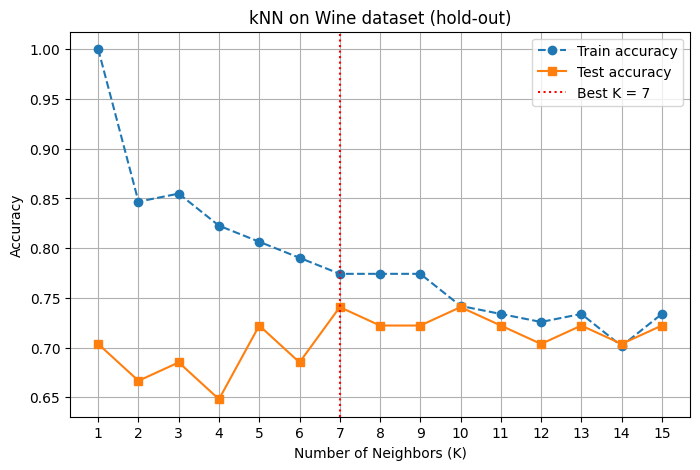

In [6]:
# #CHILLOUT: рисуем график
plt.figure(figsize=(8,5))
plt.plot(k_range, train_accuracies, label='Train accuracy', marker='o', linestyle='--')
plt.plot(k_range, test_accuracies, label='Test accuracy', marker='s', linestyle='-')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.title('kNN on Wine dataset (hold-out)')
plt.legend()
plt.grid(True)
plt.xticks(k_range)
plt.axvline(x=best_k, color='red', linestyle=':', label=f'Best K = {best_k}')
plt.legend()
plt.show()

>#DONE:
>- [x] Подобрать K (hold-out) — **сделано**.
___

# Task 3: <u>Сравнить</u> hold-out с <u>кросс-валидацией</u>